# eTraGo: electric Transmission Grid optimization

The following notebook shows you how you can apply the basic functions of eTraGo.
It is structured into two different sections: 

1) Minimal example demonstrating eTraGo's usage
2) Analyzing and disaggregating results of a representative calculation


More information on the installation of eTraGo, the described functions, as well as a description of all options, is provided in the __[eTraGo Documentation on read the docs](http://etrago.readthedocs.io/)__

## Import required general and eTraGo specific python packages

In [1]:
import warnings
warnings.filterwarnings('ignore')

from etrago import Etrago
from etrago.analyze.plot import coloring
import pypsa


In [2]:
%matplotlib inline

To decrease the calculation time, data is prepared in advance. Please adjust the path to your files accordingly. 

In [3]:
# Insert the path to the prepared data here
path = "/home/clara/etrago/data/fne_2026/"

# 1 Minimal example demonstrating eTraGo's usage

This section demonstrates the general usage of eTraGo using a minimal example.
The minimal example only considers a few snapshots, and the electrical grid is clustered to a few nodes. Thus, the results can not be used for a real analysis which requires more time steps, nodes, and therefore increased calculation time and computational resources.

The following subsections will explain and demonstrate the different functionalities given in the schema:

![Image eTraGo's functionalities](https://raw.githubusercontent.com/openego/eTraGo/0.10.1/doc/images/etrago_functionalities.png)


## 1.1 Initialize object and set parameters

All parameters of an eTraGo calculation are stored in etrago.args.
They can be defined via a json-file or as a dictionary. Documentation on all parameters is provided in the read the docs. 

In [4]:
etrago = Etrago(args={}, json_path=path+"etrago_minimal_example/args_minimal_example.json")

### Energy system scenario
The input data includes the starting grid topology as well as all energy demands, generation and sorage options. It is created with the open source tool *eGon-data*. The resulting data models are stored on the *OpenEnergyPlatform*, eTraGo directly accesses the data from there. 
In this example, the mid term scenario *eGon2035* is used, which mainly bases on the *Netzentwicklungsplan Strom 2035, Version 2021, Szenaro C 2035*.

In [5]:
# Scenario name
etrago.args["scn_name"]

'eGon2035'

### Snapshots considered in calculation
For a small example, a limited number of snapshots is selected. For larger, annual calculations eTraGo needs more RAM then a normal laptop provides, so calculations are done on a server.
The snapshots are defined as the nth number in a year, so it can be between 1 and 8760.
In this example, the first day of the year is selected:

In [6]:
print(etrago.args["start_snapshot"])
print(etrago.args["end_snapshot"])

1
24


## 1.3 Data model and scenario variation

In [7]:
#etrago.build_network_from_db()
#etrago.adjust_network()

In [8]:
etrago.network = pypsa.Network(path+"etrago_minimal_example/original_grid")

INFO:pypsa.io:Imported network original_grid has buses, generators, lines, links, loads, storage_units, stores, transformers


## 1.4 Complexity Reduction
The data model is characterized by a high spatial (about 8,000 electrical and 600 gas nodes) and temporal resolution (8,760 timesteps). To reduce the complexity of the resulting optimization problem, several methods can be applied.
In this example, we focus on the spatial complexity reduction.

This is how the network looks like in the original resolution:

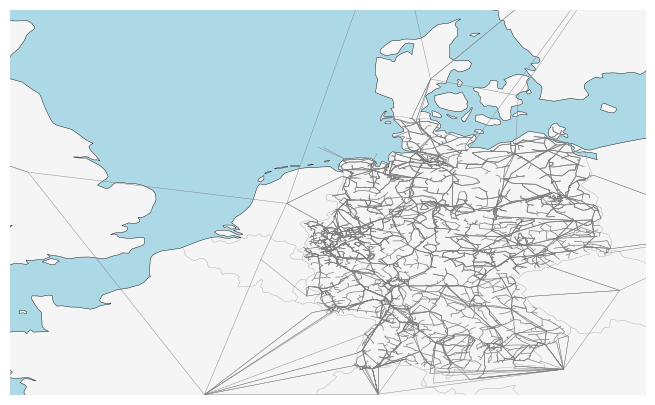

In [9]:
etrago.plot_grid("grey")

In the following, spatial complexity methods are applied. In this minimal example, the electrical network is clustered to 30 nodes.

_Please note that this step can take a few minutes. To save some time, predefined clustering results are loaded here._

In [10]:
# run spatial clustering
#etrago.spatial_clustering()
#etrago.spatial_clustering_gas()
#etrago.network.export_to_csv_folder("clustered_grid")

In [11]:
etrago.network = pypsa.Network(path+"etrago_minimal_example/clustered_grid")

INFO:pypsa.io:Imported network clustered_grid has buses, generators, lines, links, loads, storage_units, stores


Afterwards, the electrical grid looks like this:

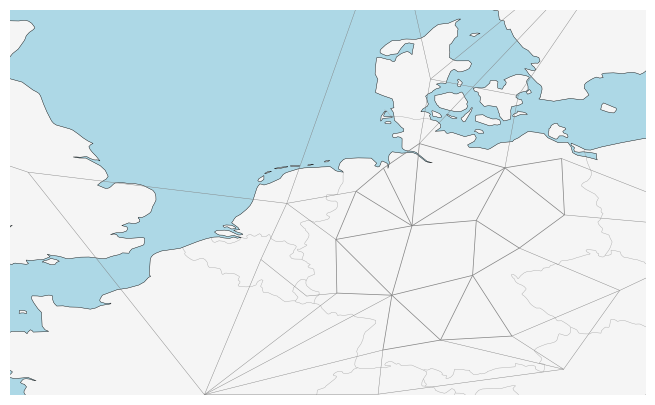

In [12]:
etrago.plot_grid("grey")

## 1.5 Optimization

eTraGo includes different methods to optimize the German energy system, including the eHV/HV grid.
In this example, an integrated LOPF is selected. This optimizes the dispatch of generation and flexibility options as well as grid and storage expansion in one integrated optimization step.

_Please note that the solver glpk needs to be installed for this minimal example._

In [13]:
etrago.optimize()

INFO:pypsa.opf:Performed preliminary steps
INFO:pypsa.opf:Building pyomo model using `kirchhoff` formulation
INFO:pypsa.opf:Solving model using glpk
INFO:pypsa.opf:Optimization successful
INFO:etrago.execute:Time for LOPF [min]: 0.39


# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 484264625.430364
  Upper bound: 484264625.430364
  Number of objectives: 1
  Number of constraints: 34729
  Number of variables: 26024
  Number of nonzeros: 84521
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 17.939709901809692
# ----------------------------------------------------------
#   Solution Information
# ----

## 1.6 Result analysis

eTraGo includes different functions to analyze the results.

_Please note that the results of the minimal example are not representative, they are just shown to explain the general usage._

In the following, a map of grid and storage expansion is visualized:

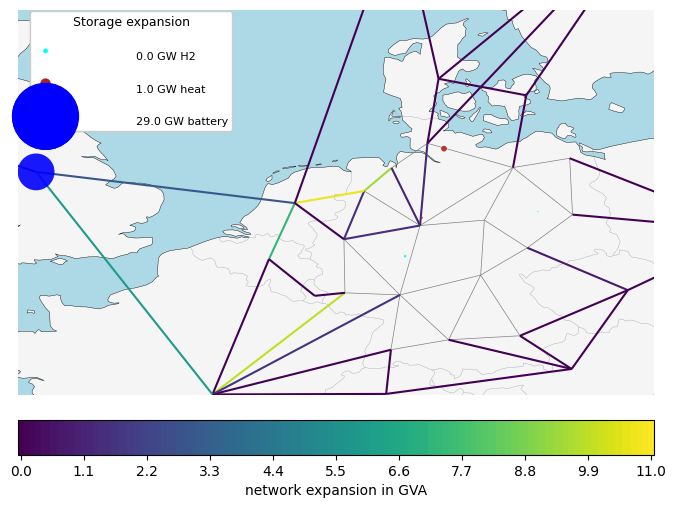

In [14]:
etrago.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 10,
                            "heat": 10,
                            "battery": 10})

# 2 Analyzing and disaggregating results of a representative calculation

eTraGo also includes several functions to analyze the results. These are demonstrated using results of a bigger calculation which are published on zenodo (https://zenodo.org/records/10160482). 

That data is also used to show the results of spatial and temporal disaggregation that is the basis for the interface to underlying distribution grids.

## 2.1 Loading predefined results

In [15]:
etrago_larger_model = Etrago(csv_folder_name=path+"etrago_predefined_results/etrago_lowflex_network")

INFO:pypsa.io:Imported network etrago_lowflex_network has buses, generators, lines, links, loads, storage_units, stores
                    No args.json in /home/clara/etrago/data/fne_2026/etrago_predefined_results/etrago_lowflex_network available.
                    
INFO:etrago.network:
                        No disaggregated network available.
                        
INFO:etrago.network:
                            No separate market model available.
                            


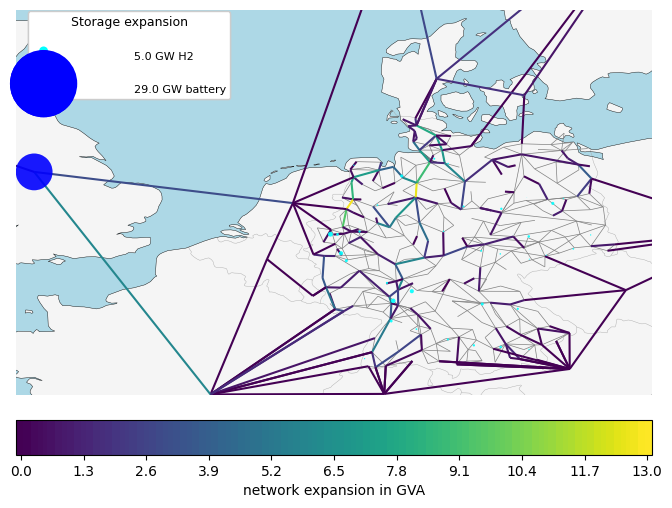

In [16]:
etrago_larger_model.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 1,
                            "battery": 10})

eTraGo also includes functions to calculate general results as tables, such as system costs and total grid expansion:

In [17]:
etrago_larger_model.calc_results()
etrago_larger_model.results.loc["annual electrical grid investment costs"]

unit                 EUR/a
value    1208150163.949301
Name: annual electrical grid investment costs, dtype: object

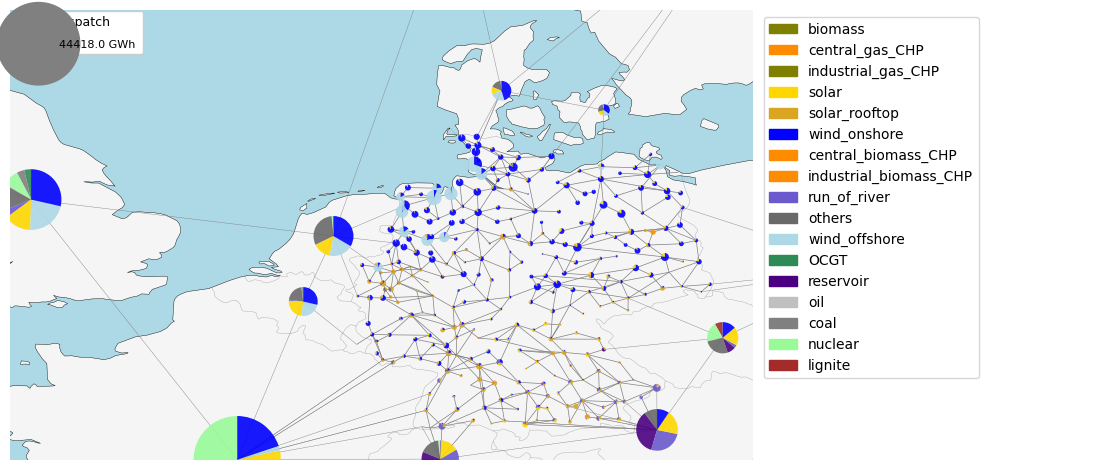

In [18]:
etrago_larger_model.plot_grid(
    line_colors="grey",
    bus_colors = "gen_dist",
    bus_sizes= 1e-8,
    timesteps = range(1752))

## 2.2 Desaggregation results to the original resolution - Interface to distribution grids

The results can be disaggregated to the original resolution in both temporal and spatial dimension. This is esp. required for the interface to the underlying distribution grids.
The grid after the disaggregation provides data for each HV/MV substation for every hour of the year:

In [19]:
etrago_larger_model.disaggregated_network = pypsa.Network(path+"etrago_predefined_results/lowflex_network_disaggregated.nc")

INFO:pypsa.io:Imported network lowflex_network_disaggregated.nc has buses, generators, lines, links, loads, storage_units, stores, transformers


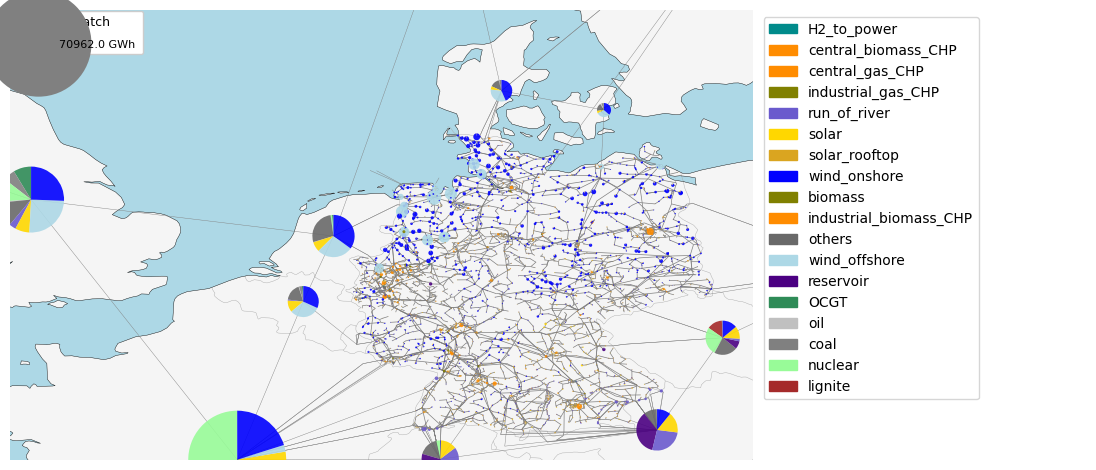

In [20]:
etrago_larger_model.plot_grid(
    line_colors="grey",
    apply_on = "disaggreagted_network",
    bus_colors = "gen_dist",
    bus_sizes= 1e-8,
    timesteps = range(1752))

<Axes: xlabel='snapshot'>

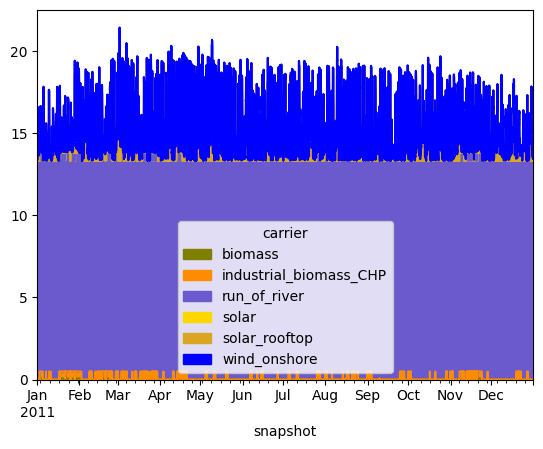

In [21]:
mv_id = "33128"

gens = etrago_larger_model.disaggregated_network.generators[etrago_larger_model.disaggregated_network.generators.bus==mv_id]

df = etrago_larger_model.disaggregated_network.generators_t.p[gens.index].groupby(gens.carrier, axis=1).sum()

df.plot(kind="area", stacked = True, color=coloring())

These dispatch time series per HV/MV substation are handed over to the underlying MV/LV grids. They are considered there as conatraints to make sure that the overall results in consistent across all voltage levels.